# Librosa feature classification workflow

In [46]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model._logistic"
)

In [47]:
BASE_DIR = os.getcwd()
METADATA_CSV = os.path.join(BASE_DIR, "fma_metadata", "tracks.csv")
FEATURE_CSV = os.path.join(BASE_DIR, "features", "features_small_essentia.csv")

RANDOM_STATE = 42
TEST_SPLITS = ("test", "validation")
PCA_COMPONENTS = 4

## Data preparation functions

In [48]:
def load_fma_small_tracks(metadata_csv):
    tracks = pd.read_csv(metadata_csv, index_col=0, header=[0, 1])
    small_tracks = tracks[tracks[("set", "subset")] == "small"]
    metadata = small_tracks[[("track", "genre_top"), ("set", "split")]].reset_index()
    metadata.columns = ["track_id", "genre_top", "split"]
    return metadata


def load_feature_table(feature_csv):
    if not os.path.exists(feature_csv):
        raise FileNotFoundError(
            f"Feature file not found: {feature_csv}. Change FEATURE_CSV to an existing file."
        )
    return pd.read_csv(feature_csv)


def attach_metadata(features_df, tracks_df):
    data = features_df.merge(
        tracks_df[["track_id", "genre_top", "split"]],
        on="track_id",
        how="left",
        validate="one_to_one",
    )
    genre = data.pop("genre_top")
    data.insert(1, "genre", genre)
    return data


def fill_numeric_missing_by_genre(data, genre_col="genre"):
    # Fill numeric missing values with genre means, then global means as fallback.
    data = data.copy()
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    grouped_means = data.groupby(genre_col)[numeric_cols].transform("mean")
    data[numeric_cols] = data[numeric_cols].fillna(grouped_means)
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())
    return data


def prepare_librosa_dataset(feature_csv, metadata_csv):
    tracks = load_fma_small_tracks(metadata_csv)
    features = load_feature_table(feature_csv)
    data = attach_metadata(features, tracks)
    data = fill_numeric_missing_by_genre(data)
    return data, tracks


def split_features(
    data,
    train_split="training",
    test_splits=TEST_SPLITS,
    target_col="genre",
    drop_cols=("track_id", "genre", "split"),
):
    
    train_mask = data["split"] == train_split
    test_mask = data["split"].isin(test_splits)

    X_train = data.loc[train_mask].drop(columns=list(drop_cols))
    y_train = data.loc[train_mask, target_col]
    X_test = data.loc[test_mask].drop(columns=list(drop_cols))
    y_test = data.loc[test_mask, target_col]

    print(f"Training tracks: {X_train.shape[0]}")
    print(f"Test (+validation) tracks: {X_test.shape[0]}")
    print(f"Feature count: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_test

## Transformation and plotting functions

In [49]:
def scale_train_test(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


def apply_pca(X_train, X_test, n_components=PCA_COMPONENTS, random_state=RANDOM_STATE):
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    return X_train_pca, X_test_pca, pca


def plot_pca_explained_variance(pca, threshold=0.70):
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    components = np.arange(1, len(cumulative) + 1)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=components, y=cumulative, color="skyblue")
    plt.axhline(y=threshold, color="red", linestyle="--", label=f"{threshold:.0%} variance")
    for i, value in enumerate(cumulative):
        plt.text(i, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.legend()
    plt.show()


def plot_pca_scatter(X_train_pca, y_train):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette="Set2")
    plt.title("PC1 vs PC2")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Genre")
    plt.show()


def draw_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

## Modelling functions

In [50]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, print_report=False):
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred_train = fitted_model.predict(X_train)
    y_pred_test = fitted_model.predict(X_test)

    result = {
        "name": name,
        "model": fitted_model,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test,
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "macro_f1": f1_score(y_test, y_pred_test, average="macro"),
    }

    print(f"{name} Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"{name} Test Accuracy: {result['test_accuracy']:.4f}")
    print(f"{name} Macro F1: {result['macro_f1']:.4f}")

    if print_report:
        print()
        print(f"Classification Report - {name}:")
        print(classification_report(y_test, y_pred_test))

    return result


def run_model_suite(model_specs, X_train, X_test, y_train, y_test, print_report=False):
    results = {}
    for name, model in model_specs:
        print("-" * 60)
        results[name] = evaluate_classifier(
            name,
            model,
            X_train,
            X_test,
            y_train,
            y_test,
            print_report=print_report,
        )

    summary = pd.DataFrame(
        [
            {
                "model": name,
                "train_accuracy": result["train_accuracy"],
                "test_accuracy": result["test_accuracy"],
                "macro_f1": result["macro_f1"],
            }
            for name, result in results.items()
        ]
    ).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

    return summary, results

def get_lightgbm_classifier():
    from lightgbm import LGBMClassifier

    return LGBMClassifier(
        n_estimators=50,
        learning_rate=0.04,
        max_depth=5,
        random_state=RANDOM_STATE,
        verbose=-1,
    )


def pca_model_specs():
    return [
        ("SVM linear + PCA", SVC(kernel="linear", C=1, random_state=RANDOM_STATE)),
        ("SVM RBF + PCA", SVC(kernel="rbf", C=0.1, gamma=0.01, random_state=RANDOM_STATE)),
        (
            "Random Forest + PCA",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=7,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            ),
        ),
    ]


def no_pca_model_specs():
    specs = [
        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=7,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            ),
        ),
        ("SVM linear", SVC(kernel="linear", C=1, random_state=RANDOM_STATE)),
        ("SVM RBF", SVC(kernel="rbf", C=0.1, gamma=0.01, random_state=RANDOM_STATE)),
        (
            "Logistic Regression",
            LogisticRegression(C=10, penalty="l2", solver="lbfgs", random_state=RANDOM_STATE, max_iter=500),
        ),
        (
            "Gradient Boosting",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.01,
                max_depth=4,
                subsample=0.8,
                random_state=RANDOM_STATE,
            ),
        ),
    ]

    lgbm = get_lightgbm_classifier()
    if lgbm is not None:
        specs.insert(3, ("LightGBM", lgbm))

    return specs


def draw_result_confusion_matrix(results, model_name, y_test, title=None):
    result = results[model_name]
    draw_confusion_matrix(
        y_test,
        result["y_pred_test"],
        result["model"].classes_,
        title or f"Confusion Matrix - {model_name}",
    )

## Load and prepare data

In [51]:
df, df_tracks = prepare_librosa_dataset(FEATURE_CSV, METADATA_CSV)

display(df.head(3))
print(df.shape)
display(df["split"].value_counts().reset_index(drop=True))
display(df["genre"].value_counts().reset_index(drop=True))

,track_id,genre,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,split
0,120161,Experimental,0.248257,0.202268,0.244151,0.213059,0.186713,0.332705,0.300959,0.260288,...,167.947281,156.098038,125.217270,0.090741,0.0,0.083298,0.0,0.037109,0.0,training
1,120325,Instrumental,0.229105,0.274468,0.221760,0.211825,0.223252,0.222400,0.244372,0.232793,...,151.245316,151.892273,152.419739,0.048890,0.0,0.083314,0.0,0.040039,0.0,training
2,120315,Instrumental,0.205081,0.209108,0.208540,0.207055,0.194353,0.173302,0.168125,0.175548,...,124.726662,125.769249,125.392563,0.077853,0.0,0.126783,0.0,0.048828,0.0,training


(8000, 73)


0    6400
1     800
2     800
Name: count, dtype: int64

0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
Name: count, dtype: int64

In [52]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
display(missing_summary.head(10))
display(df.describe())

track_id               0
genre                  0
chroma_stft_mean_01    0
chroma_stft_mean_02    0
chroma_stft_mean_03    0
chroma_stft_mean_04    0
chroma_stft_mean_05    0
chroma_stft_mean_06    0
chroma_stft_mean_07    0
chroma_stft_mean_08    0
dtype: int64

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0,8000.000000,8000.0,8000.000000,8000.0
mean,84126.770125,0.242294,0.243932,0.240048,0.238095,0.239471,0.238722,0.238573,0.237796,0.238415,...,137.368320,137.435442,137.527539,137.531830,0.104174,0.0,0.158083,0.0,0.054996,0.0
std,43297.426287,0.074052,0.082360,0.084509,0.084086,0.085298,0.084552,0.084161,0.083857,0.084536,...,28.580710,28.544770,28.547717,28.577711,0.075527,0.0,0.084763,0.0,0.031717,0.0
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,68.418961,68.131493,68.389275,68.790649,0.000000,0.0,0.000000,0.0,0.000000,0.0
25%,49063.500000,0.191216,0.186677,0.180965,0.179268,0.179459,0.179100,0.179001,0.179590,0.179185,...,117.363411,117.333597,117.646952,117.236366,0.046769,0.0,0.095627,0.0,0.035645,0.0
50%,89281.000000,0.234690,0.233432,0.228746,0.226369,0.226714,0.227675,0.227270,0.226714,0.228794,...,132.416779,132.472389,132.325508,132.636329,0.088045,0.0,0.144991,0.0,0.048340,0.0
75%,122545.000000,0.284610,0.292624,0.290052,0.286745,0.288705,0.287320,0.287513,0.285806,0.288125,...,152.169605,152.065537,152.250805,152.102425,0.143361,0.0,0.203852,0.0,0.065918,0.0
max,155066.000000,0.650920,0.611137,0.662664,0.755007,0.629681,0.616529,0.610078,0.608662,0.669806,...,276.045441,275.803864,276.272552,276.304718,0.574145,0.0,0.627993,0.0,0.352051,0.0


## Train/test split

In [53]:
X_train, X_test, y_train, y_test = split_features(df)
display(X_test.head(3))

Training tracks: 6400
Test (+validation) tracks: 1600
Feature count: 70


,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,chroma_stft_mean_10,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
13,0.200428,0.286764,0.276048,0.238580,0.259628,0.233271,0.208774,0.204744,0.208097,0.218117,...,107.896950,109.348595,110.178726,109.669678,0.198059,0.0,0.126418,0.0,0.039062,0.0
22,0.261797,0.471882,0.199989,0.232732,0.205998,0.263873,0.219157,0.206898,0.275383,0.451400,...,121.433197,118.920311,118.268425,120.286606,0.051228,0.0,0.129050,0.0,0.036621,0.0
26,0.171209,0.176911,0.347120,0.206717,0.161957,0.137176,0.144573,0.232138,0.349075,0.241973,...,114.103752,116.057762,116.957794,117.886238,0.085903,0.0,0.162392,0.0,0.042480,0.0


## PCA workflow

PCA train shape: (6400, 4)


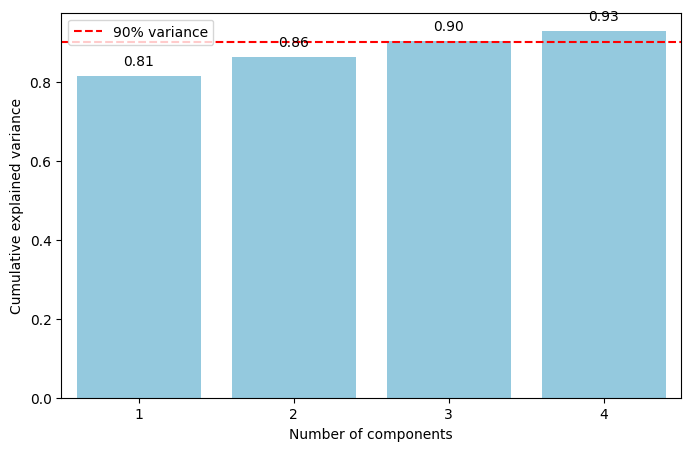

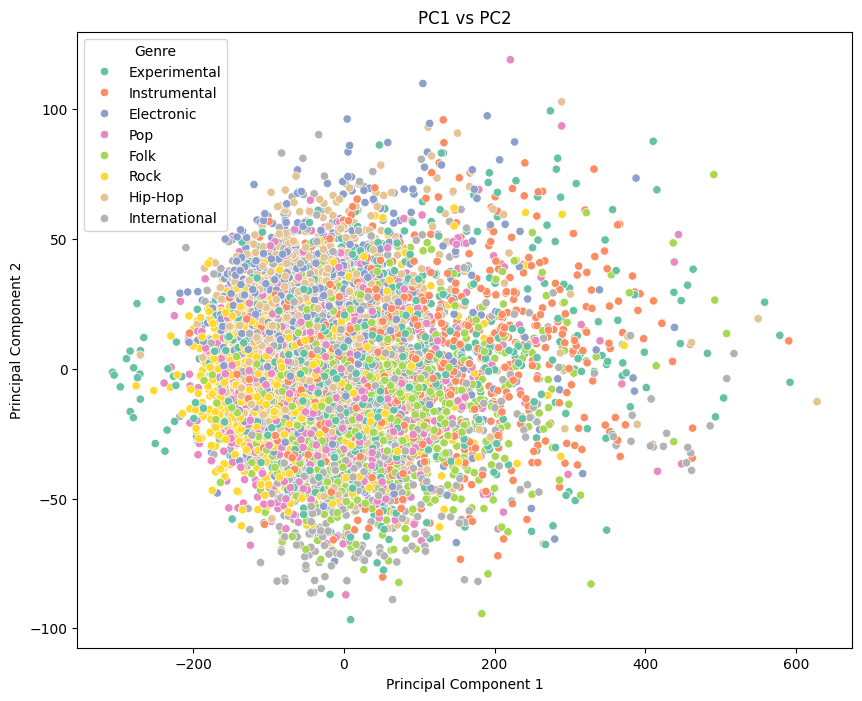

In [54]:
X_train_pca_raw, X_test_pca_raw, pca = apply_pca(X_train, X_test, n_components=PCA_COMPONENTS)
print(f"PCA train shape: {X_train_pca_raw.shape}")

plot_pca_explained_variance(pca, threshold=0.90)
plot_pca_scatter(X_train_pca_raw, y_train)

In [55]:
X_train_pca, X_test_pca, pca_scaler = scale_train_test(X_train_pca_raw, X_test_pca_raw)

pca_summary, pca_results = run_model_suite(
    pca_model_specs(),
    X_train_pca,
    X_test_pca,
    y_train,
    y_test,
)

display(pca_summary)

------------------------------------------------------------
SVM linear + PCA Train Accuracy: 0.2864
SVM linear + PCA Test Accuracy: 0.2556
SVM linear + PCA Macro F1: 0.2279
------------------------------------------------------------
SVM RBF + PCA Train Accuracy: 0.2850
SVM RBF + PCA Test Accuracy: 0.2362
SVM RBF + PCA Macro F1: 0.1923
------------------------------------------------------------
Random Forest + PCA Train Accuracy: 0.3984
Random Forest + PCA Test Accuracy: 0.2487
Random Forest + PCA Macro F1: 0.2219


,model,train_accuracy,test_accuracy,macro_f1
0,SVM linear + PCA,0.286406,0.255625,0.227891
1,Random Forest + PCA,0.398438,0.248750,0.221883
2,SVM RBF + PCA,0.285000,0.236250,0.192270


## Confusion matrices for PCA models

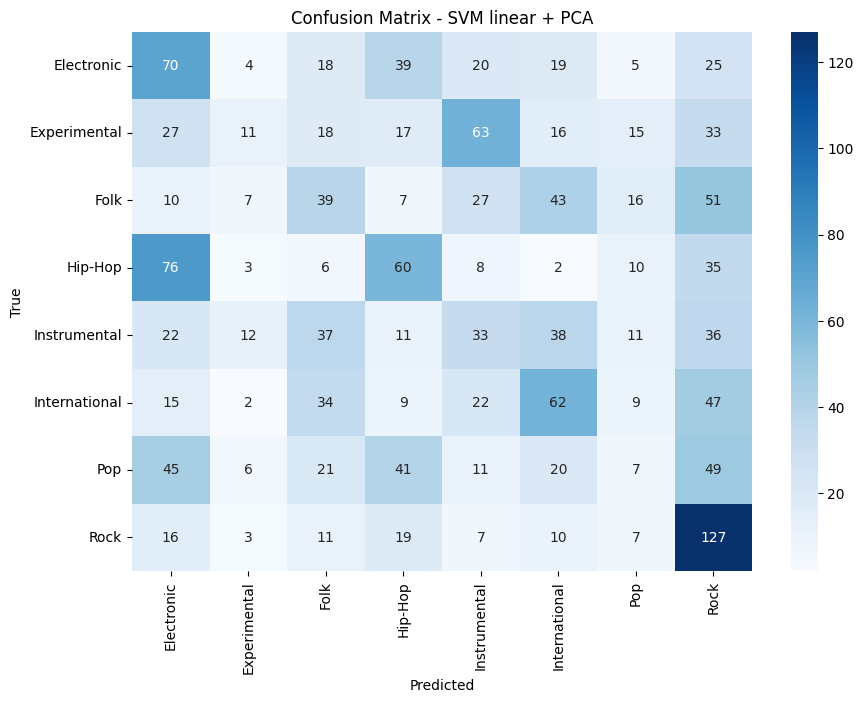

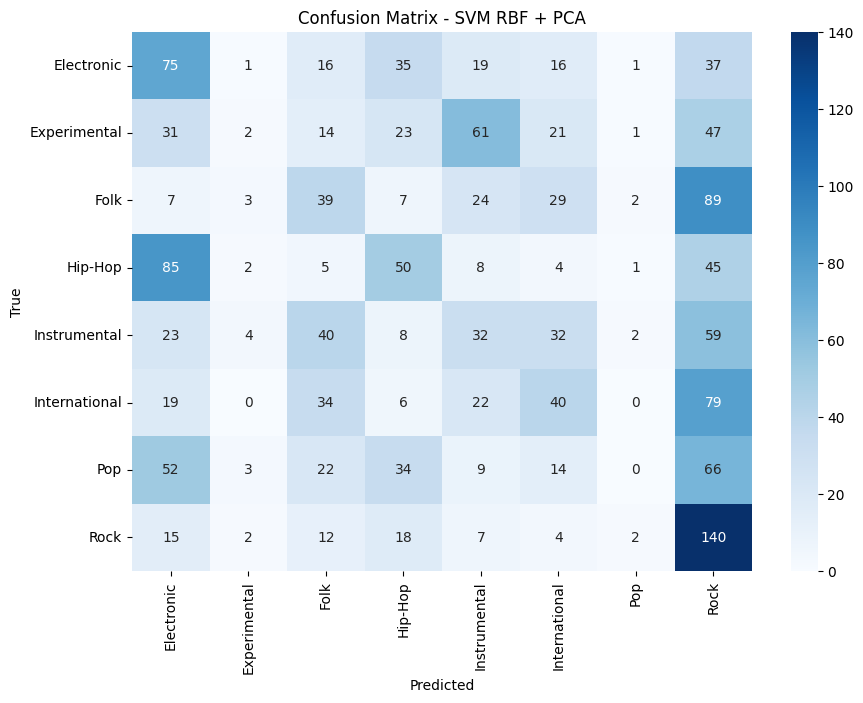

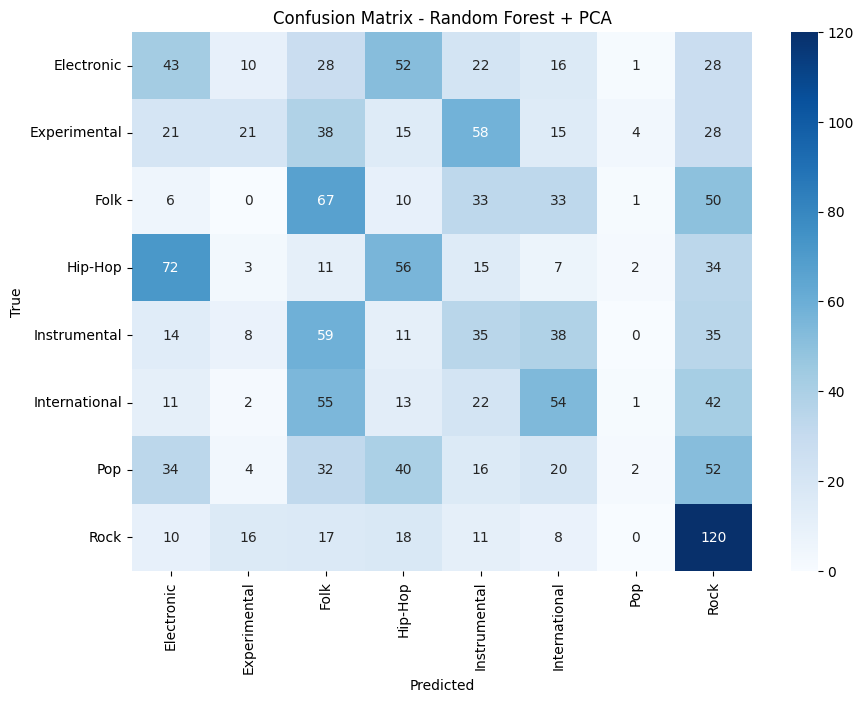

In [56]:
for model_name in pca_results:
    draw_result_confusion_matrix(
        pca_results,
        model_name,
        y_test,
        f"Confusion Matrix - {model_name}",
    )

## Modeling without PCA

In [57]:
X_train_scaled, X_test_scaled, scaler = scale_train_test(X_train, X_test)
print(f"No-PCA train shape: {X_train_scaled.shape}")

no_pca_summary, no_pca_results = run_model_suite(
    no_pca_model_specs(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
)

display(no_pca_summary.reset_index(drop=True))

No-PCA train shape: (6400, 70)
------------------------------------------------------------
Random Forest Train Accuracy: 0.5059
Random Forest Test Accuracy: 0.2994
Random Forest Macro F1: 0.2779
------------------------------------------------------------
SVM linear Train Accuracy: 0.3622
SVM linear Test Accuracy: 0.2956
SVM linear Macro F1: 0.2861
------------------------------------------------------------
SVM RBF Train Accuracy: 0.3427
SVM RBF Test Accuracy: 0.3013
SVM RBF Macro F1: 0.2812
------------------------------------------------------------
LightGBM Train Accuracy: 0.6031
LightGBM Test Accuracy: 0.3006
LightGBM Macro F1: 0.2862
------------------------------------------------------------
Logistic Regression Train Accuracy: 0.3519
Logistic Regression Test Accuracy: 0.2913
Logistic Regression Macro F1: 0.2793
------------------------------------------------------------
Gradient Boosting Train Accuracy: 0.4959
Gradient Boosting Test Accuracy: 0.3031
Gradient Boosting Macro F1

,model,train_accuracy,test_accuracy,macro_f1
0,Gradient Boosting,0.495937,0.303125,0.286982
1,SVM RBF,0.342656,0.301250,0.281176
2,LightGBM,0.603125,0.300625,0.286236
3,Random Forest,0.505938,0.299375,0.277885
4,SVM linear,0.362187,0.295625,0.286104
5,Logistic Regression,0.351875,0.291250,0.279299


## Confusion matrices for selected models

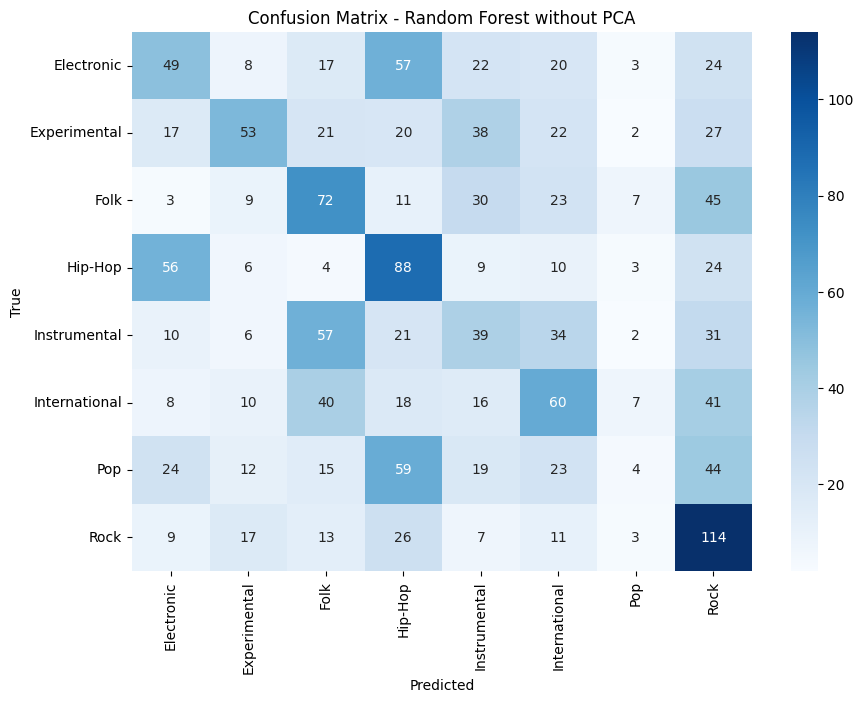

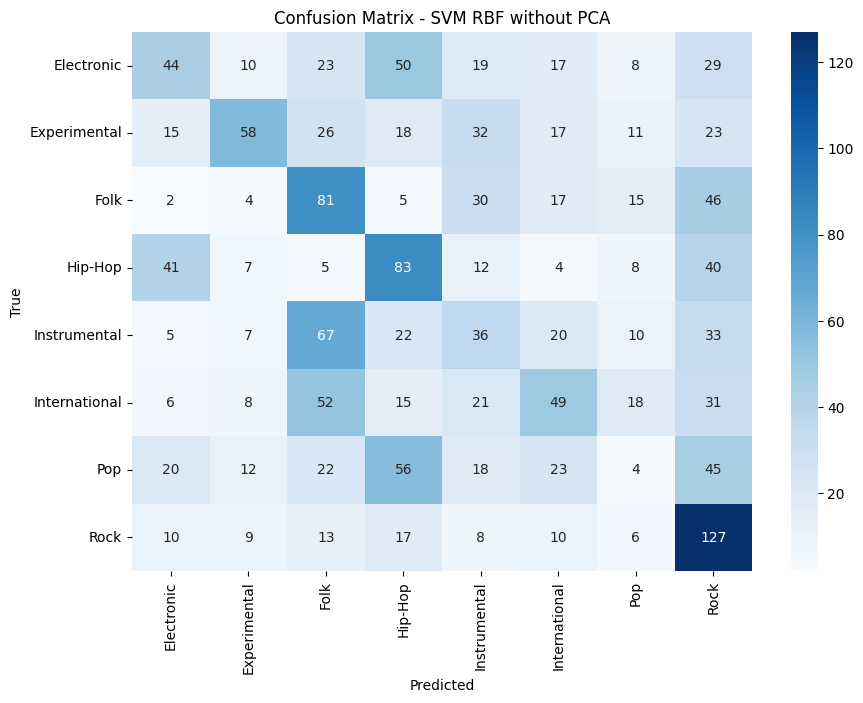

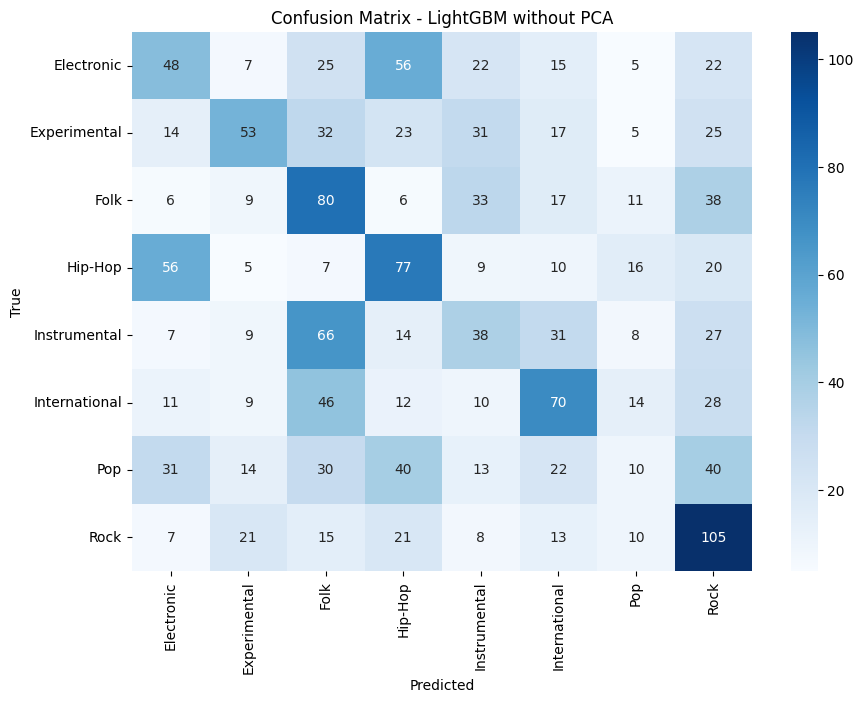

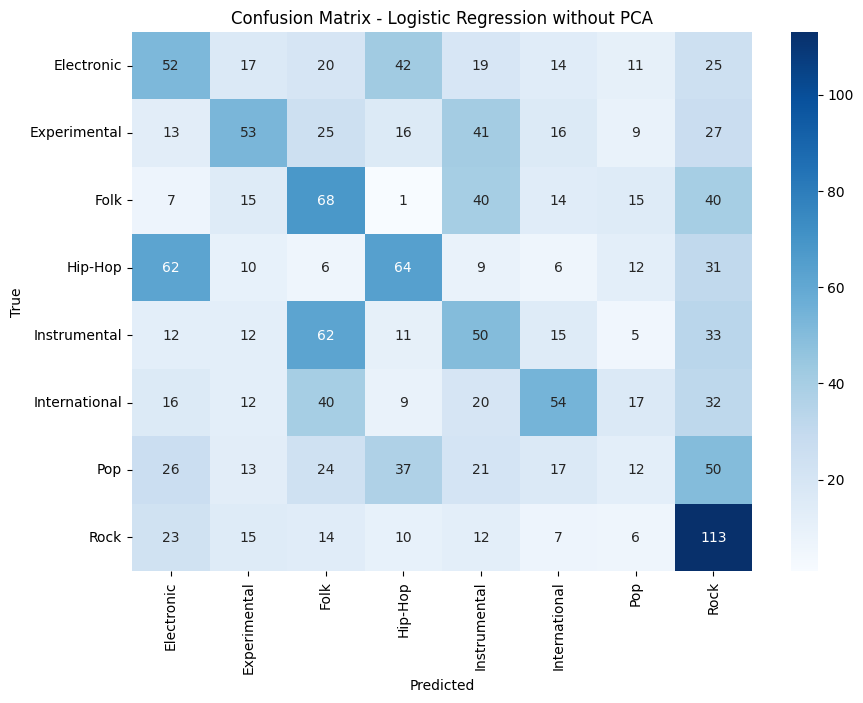

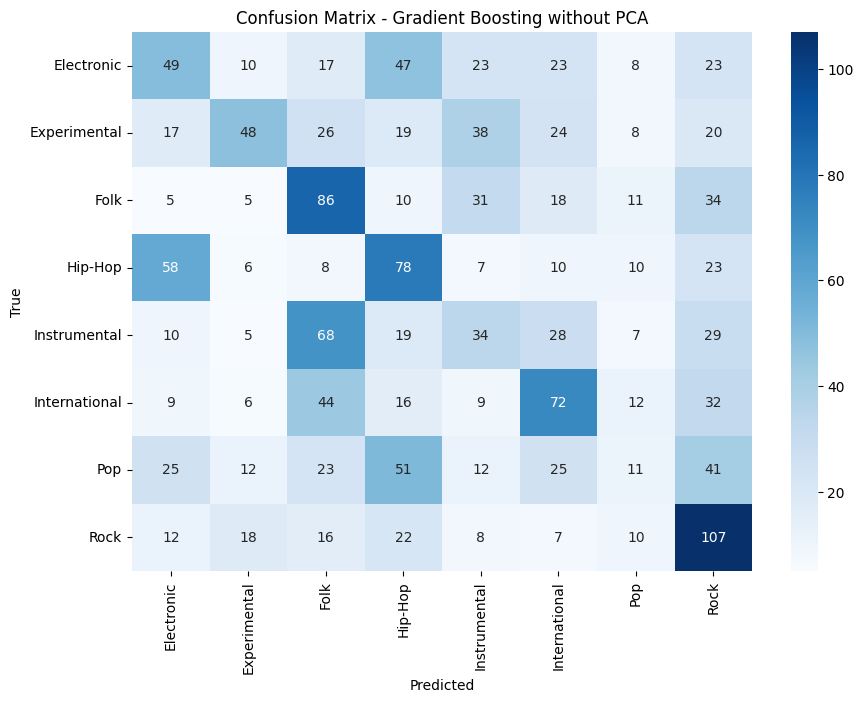

In [58]:
draw_result_confusion_matrix(no_pca_results, "Random Forest", y_test, "Confusion Matrix - Random Forest without PCA")
draw_result_confusion_matrix(no_pca_results, "SVM RBF", y_test, "Confusion Matrix - SVM RBF without PCA")

if "LightGBM" in no_pca_results:
    draw_result_confusion_matrix(no_pca_results, "LightGBM", y_test, "Confusion Matrix - LightGBM without PCA")

draw_result_confusion_matrix(no_pca_results, "Logistic Regression", y_test, "Confusion Matrix - Logistic Regression without PCA")
draw_result_confusion_matrix(no_pca_results, "Gradient Boosting", y_test, "Confusion Matrix - Gradient Boosting without PCA")

## Combined result table

In [59]:
combined_summary = pd.concat(
    [
        pca_summary.assign(representation="PCA top 4"),
        no_pca_summary.assign(representation="No PCA"),
    ],
    ignore_index=True,
).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

display(combined_summary)

,model,train_accuracy,test_accuracy,macro_f1,representation
0,Gradient Boosting,0.495937,0.303125,0.286982,No PCA
1,SVM RBF,0.342656,0.301250,0.281176,No PCA
2,LightGBM,0.603125,0.300625,0.286236,No PCA
3,Random Forest,0.505938,0.299375,0.277885,No PCA
4,SVM linear,0.362187,0.295625,0.286104,No PCA
5,Logistic Regression,0.351875,0.291250,0.279299,No PCA
6,SVM linear + PCA,0.286406,0.255625,0.227891,PCA top 4
7,Random Forest + PCA,0.398438,0.248750,0.221883,PCA top 4
8,SVM RBF + PCA,0.285000,0.236250,0.192270,PCA top 4
